# RecSys EDA — Phase 0: 환경·데이터 파악

**목적**: `train.parquet` 탐색을 통해 모델 선택 및 검증 전략 수립에 필요한 인사이트 확보

**평가 지표**: Binary Relevance NDCG@10  
**제출 형식**: 638,257 유저 × Top-10 아이템 (중복 없음)

---
### 체크리스트
> **실행 반영 요약** (섹션 15 요약 셀 출력 기준): 유저 **638,257** · 아이템 **29,502** · 인터랙션 **8,350,311** · 희소성 **~99.96%** · 기간 **120일** · 캘린더 검증 **마지막 7일** · 연속 이벤트 간격 **CV≈4.12** · 시퀀스 권장 길이 **29** (노트북 코드 기준) · 롱 시퀀스 **>50 유저 ~4.1%**

- [x] 기본 스키마 및 크기 확인 (`train.parquet` 8열·결측 0, `sample_submission` 형식)
- [x] 유저·아이템 분포 (롱테일 정도) — 섹션 2·5, 아이템 인기도 로그-로그·커버리지
- [x] **아이템 반복도**(view+cart+purchase 전 행 기준, 구매 재구매 아님) → SAFERec / TIFU-KNN 판단 — 섹션 6 (평균 **~14.63%**)
- [x] 연속 이벤트 간격(time gap) 분포 → TiSASRec 판단 — 섹션 7 (**CV≈4.12**)
- [x] 시퀀스 길이 분포 → Mamba4Rec 판단 — 섹션 4·14 (롱 **>50** ~**4.1%**)
- [x] 행동 전환(view→cart→purchase) 및 cart 상품 특성 — 섹션 8
- [x] purchase 시간·요일 패턴 — 섹션 9
- [x] 인기 카테고리·브랜드 — 섹션 10
- [x] 구매 가격대 — 섹션 11
- [x] 세션 구조 분석 — 섹션 12 + 섹션 5-1 `event_type` 분포
- [x] 시간 범위 및 캘린더 검증 분할 기준 확정 — 섹션 3 일별 추이·holdout, 섹션 13 검증 유저 커버리지

## 0. 라이브러리 로드

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_DIR = Path('../data')
print('Data dir:', DATA_DIR.resolve())

Data dir: /data/ephemeral/home/recsys/data


## 1. 데이터 로드 및 기본 스키마

In [39]:
df = pd.read_parquet(DATA_DIR / 'train.parquet')
df['event_time'] = pd.to_datetime(df['event_time'], format='%Y-%m-%d %H:%M:%S %Z', utc=True)

print('=== 기본 정보 ===')
print(f'행 수        : {len(df):,}')
print(f'열 수        : {df.shape[1]}')
print(f'메모리 사용량 : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
df.dtypes

=== 기본 정보 ===
행 수        : 8,350,311
열 수        : 8
메모리 사용량 : 4177.7 MB



user_id                       object
item_id                       object
user_session                  object
event_time       datetime64[ns, UTC]
category_code                 object
brand                         object
price                        float64
event_type                    object
dtype: object

In [5]:
print('=== 결측치 ===')
print(df.isnull().sum())
print()
df.head(10)

=== 결측치 ===
user_id          0
item_id          0
user_session     0
event_time       0
category_code    0
brand            0
price            0
event_type       0
dtype: int64



,user_id,item_id,user_session,event_time,category_code,brand,price,event_type
0,0b517454-e7c3-44ec-8c39-a68ef9c0ec60,18c11cbb-a18d-4a9e-bdea-6abd3f7d3c04,ad97f19a-f5fb-41ea-a7b2-52c21fb37ab2,2019-11-16 16:31:26+00:00,apparel.shoes,kapika,72.05,view
1,215eeee5-f9c5-4213-8641-7561dbdad1b9,47c5a6da-32d0-4a29-8b51-57304f476ded,6058b45b-bdb9-4d6c-b300-42dcb1cb8280,2019-11-04 18:59:50+00:00,apparel.shoes,respect,82.63,view
2,a25bf14a-49ac-49bb-87de-ee6b300f0cc4,a6d915c6-2bb7-4393-a556-c327723d3666,28a8b8e3-b374-435d-9d5d-b96058ecb75b,2019-11-26 09:01:47+00:00,apparel.tshirt,goodloot,24.43,view
3,09ee8591-25e0-4bb4-ae24-c48ed4212e3c,0fd4da5d-989c-4a75-9ace-2b108f834c8c,f2972db7-9916-4a58-b6f9-c76afde6245e,2019-11-15 16:05:34+00:00,apparel.shoes,baden,70.79,view
4,7acf7c81-69f6-4aa8-b19f-8e85aeaffc28,d52d1c91-5534-4de4-aaf1-318e932e10e7,7d46d970-b40e-4a2f-81a7-65bf23aa0aae,2019-11-16 13:14:09+00:00,apparel.shoes,rooman,53.80,view
5,7acf7c81-69f6-4aa8-b19f-8e85aeaffc28,2933991a-32a4-4a87-855e-1879a64cd590,7d46d970-b40e-4a2f-81a7-65bf23aa0aae,2019-11-16 13:15:18+00:00,apparel.shoes,respect,64.61,view
6,ae46c8ec-1747-4d98-b15e-8dfe89f6986c,476e0658-d99b-4ca6-b337-3a0d46018128,be04d3f9-ad4c-47a3-8989-3ab980d5b689,2019-11-21 15:41:18+00:00,apparel.shoes,respect,89.84,view
7,ae46c8ec-1747-4d98-b15e-8dfe89f6986c,d1f7b907-e3d8-4969-87f8-feebf46b0646,be04d3f9-ad4c-47a3-8989-3ab980d5b689,2019-11-21 15:42:10+00:00,apparel.shoes,respect,69.24,view
8,ae46c8ec-1747-4d98-b15e-8dfe89f6986c,e77c501d-6972-4aeb-b1d5-6422e2e31705,be04d3f9-ad4c-47a3-8989-3ab980d5b689,2019-11-21 15:42:41+00:00,apparel.shoes,respect,98.84,view
9,cd397d08-d078-40cf-9c23-a79fee33efd6,266d2131-1420-4921-826c-c95bdf665caa,8d9ad21e-20a5-43d6-92db-e721c3918569,2019-11-30 10:37:18+00:00,apparel.skirt,weekend,432.44,view


In [6]:
sub = pd.read_csv(DATA_DIR / 'sample_submission.csv')
print('=== sample_submission.csv ===')
print(sub.shape)
sub.head()

=== sample_submission.csv ===
(6382570, 2)


,user_id,item_id
0,0000162d-72b9-4b0f-8895-7b52b6661c82,59e492d8-994e-4328-8a8d-4f51d3cc23f3
1,0000162d-72b9-4b0f-8895-7b52b6661c82,3f2eebd4-b070-4140-8618-63839c4f9524
2,0000162d-72b9-4b0f-8895-7b52b6661c82,586c4927-df6e-4ee3-a02b-c877f8ea1159
3,0000162d-72b9-4b0f-8895-7b52b6661c82,0833ccaa-0a09-4619-b477-4a4f74a22253
4,0000162d-72b9-4b0f-8895-7b52b6661c82,235dac51-966d-4497-85e1-1b0173d76ed0


## 2. 유저 · 아이템 기본 통계

In [7]:
n_users    = df['user_id'].nunique()
n_items    = df['item_id'].nunique()
n_sessions = df['user_session'].nunique()
sparsity   = 1 - len(df) / (n_users * n_items)

print(f'유저 수        : {n_users:,}')
print(f'아이템 수      : {n_items:,}')
print(f'세션 수        : {n_sessions:,}')
print(f'전체 인터랙션  : {len(df):,}')
print(f'희소성(Sparsity): {sparsity:.6f} ({sparsity*100:.4f}%)')
print()
print(f'제출 라인 수   : {len(sub):,}')
print(f'학습 유저와 제출 유저 일치 여부: {set(sub.iloc[:,0].astype(str)) <= set(df["user_id"].astype(str))}')

유저 수        : 638,257
아이템 수      : 29,502
세션 수        : 2,889,552
전체 인터랙션  : 8,350,311
희소성(Sparsity): 0.999557 (99.9557%)

제출 라인 수   : 6,382,570
학습 유저와 제출 유저 일치 여부: True


In [8]:
for col in ["category_code", "brand", "event_type"]:
    print(f"\n=== {col} 고유값 개수: {df[col].nunique(dropna=False)} ===")
    print(df[col].unique())


=== category_code 고유값 개수: 24 ===
['apparel.shoes' 'apparel.tshirt' 'apparel.skirt' 'apparel.shoes.keds'
 'apparel.shoes.moccasins' 'apparel.dress' 'apparel.costume'
 'apparel.jumper' 'apparel.glove' 'apparel.trousers' 'apparel.underwear'
 'apparel.shirt' 'apparel.shoes.sandals' 'apparel.jeans'
 'apparel.shoes.ballet_shoes' 'apparel.scarf' 'apparel.shoes.espadrilles'
 'apparel.shoes.slipons' 'apparel.shoes.step_ins' 'apparel.belt'
 'apparel.sock' 'apparel.shorts' 'apparel.pajamas' 'apparel.jacket']

=== brand 고유값 개수: 1859 ===
['kapika' 'respect' 'goodloot' ... 'huanger' 'lorain' 'baobaohao']

=== event_type 고유값 개수: 3 ===
['view' 'purchase' 'cart']


## 3. 시간 범위 및 캘린더 검증 분할

In [9]:
t_min = df['event_time'].min()
t_max = df['event_time'].max()
total_days = (t_max - t_min).days

print(f'시작 시각 : {t_min}')
print(f'종료 시각 : {t_max}')
print(f'전체 기간 : {total_days} 일')

# 캘린더 기반 검증 분할 기준
val_cutoff = t_max - pd.Timedelta(days=7)
print(f'\n[캘린더 검증 분할]')
print(f'  학습 구간  : ~ {val_cutoff}')
print(f'  검증 구간  : {val_cutoff} ~ {t_max}  (7일)')

train_mask = df['event_time'] < val_cutoff
val_mask   = df['event_time'] >= val_cutoff
print(f'  학습 행 수 : {train_mask.sum():,}')
print(f'  검증 행 수 : {val_mask.sum():,}')

시작 시각 : 2019-11-01 00:00:17+00:00
종료 시각 : 2020-02-29 23:59:33+00:00
전체 기간 : 120 일

[캘린더 검증 분할]
  학습 구간  : ~ 2020-02-22 23:59:33+00:00
  검증 구간  : 2020-02-22 23:59:33+00:00 ~ 2020-02-29 23:59:33+00:00  (7일)
  학습 행 수 : 8,016,284
  검증 행 수 : 334,027


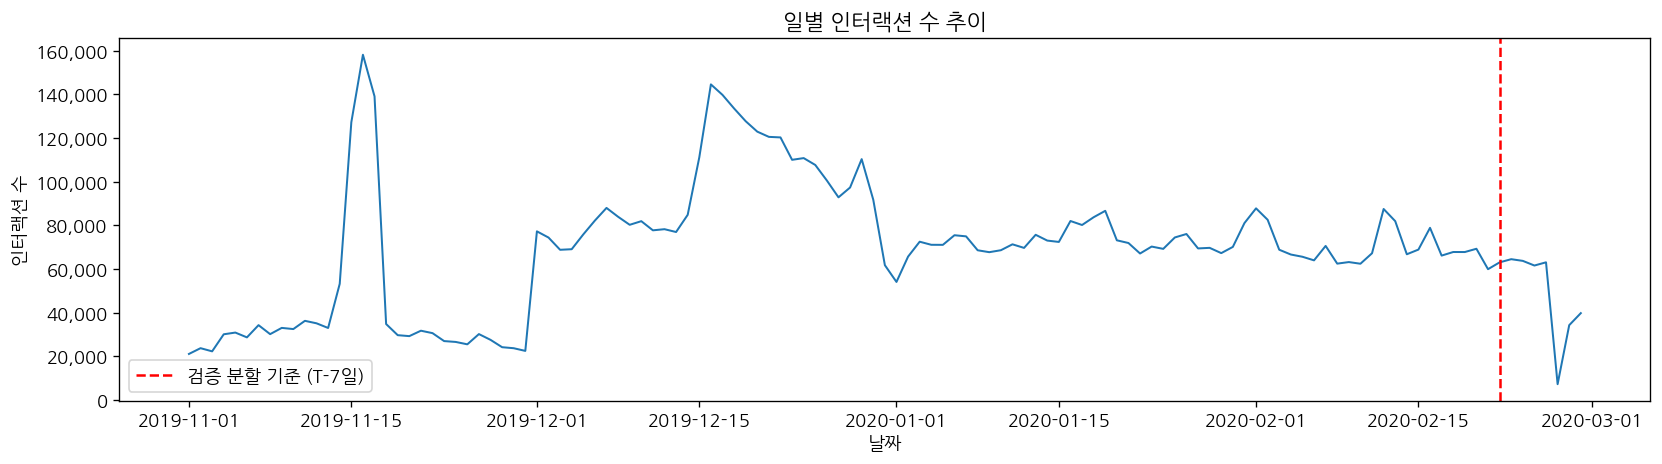

In [10]:
# 한글 폰트 등록 
from matplotlib import font_manager as fm

fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
_nanum = fm.FontProperties(fname="/usr/share/fonts/truetype/nanum/NanumGothic.ttf")

# 일별 인터랙션 수 추이
df['date'] = df['event_time'].dt.date
daily = df.groupby('date').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily['date'], daily['count'], linewidth=1.2)
ax.axvline(pd.Timestamp(val_cutoff).date(), color='red', linestyle='--', label='검증 분할 기준 (T-7일)')
ax.set_title("일별 인터랙션 수 추이")
ax.set_xlabel("날짜")
ax.set_ylabel("인터랙션 수")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 4. 유저별 인터랙션 분포 (시퀀스 길이)

In [11]:
user_cnt = df.groupby('user_id').size()

print('=== 유저별 인터랙션 수 통계 ===')
print(user_cnt.describe(percentiles=[.25, .5, .75, .90, .95, .99]).to_string())
print()
print(f'인터랙션 1건 유저 : {(user_cnt == 1).sum():,} ({(user_cnt==1).mean()*100:.1f}%)')
print(f'인터랙션 5건 이하 : {(user_cnt <= 5).sum():,} ({(user_cnt<=5).mean()*100:.1f}%)')
print(f'인터랙션 50건 초과: {(user_cnt > 50).sum():,} ({(user_cnt>50).mean()*100:.1f}%)')
print()
# Mamba4Rec 적용 가이드
long_seq_ratio = (user_cnt > 50).mean()
if long_seq_ratio > 0.2:
    print(f'[권고] 긴 시퀀스 유저 비율 {long_seq_ratio*100:.1f}% → Mamba4Rec 검토 필요')
else:
    print(f'[권고] 긴 시퀀스 유저 비율 {long_seq_ratio*100:.1f}% → SASRec/BSARec 우선, Mamba4Rec 후순위')

=== 유저별 인터랙션 수 통계 ===
count    638257.000000
mean         13.082992
std          58.804251
min           1.000000
25%           2.000000
50%           6.000000
75%          15.000000
90%          29.000000
95%          45.000000
99%         102.000000
max       37207.000000

인터랙션 1건 유저 : 107,422 (16.8%)
인터랙션 5건 이하 : 302,903 (47.5%)
인터랙션 50건 초과: 25,897 (4.1%)

[권고] 긴 시퀀스 유저 비율 4.1% → SASRec/BSARec 우선, Mamba4Rec 후순위


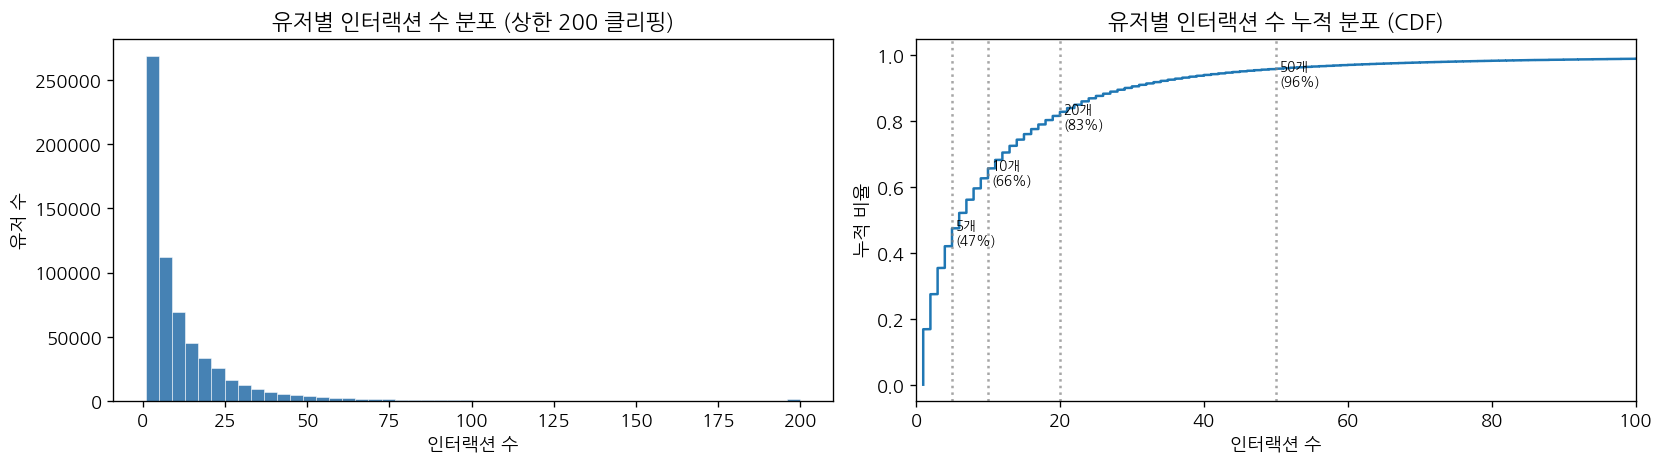

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 로그 스케일 히스토그램
axes[0].hist(user_cnt.clip(upper=200), bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('유저별 인터랙션 수 분포 (상한 200 클리핑)')
axes[0].set_xlabel('인터랙션 수')
axes[0].set_ylabel('유저 수')

# 누적 분포 (CDF)
sorted_cnt = np.sort(user_cnt.values)
cdf = np.arange(1, len(sorted_cnt)+1) / len(sorted_cnt)
axes[1].plot(sorted_cnt, cdf, linewidth=1.5)
for threshold in [5, 10, 20, 50]:
    pct = (user_cnt <= threshold).mean()
    axes[1].axvline(threshold, color='gray', linestyle=':', alpha=0.7)
    axes[1].text(threshold+0.5, pct-0.05, f'{threshold}개\n({pct*100:.0f}%)', fontsize=8)
axes[1].set_title('유저별 인터랙션 수 누적 분포 (CDF)')
axes[1].set_xlabel('인터랙션 수')
axes[1].set_ylabel('누적 비율')
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

## 5. 아이템 인기도 분포 (롱테일)

In [13]:
item_cnt = df.groupby('item_id').size().sort_values(ascending=False)

print('=== 아이템별 인터랙션 수 통계 ===')
print(item_cnt.describe(percentiles=[.25, .5, .75, .90, .95, .99]).to_string())
print()
print(f'인터랙션 1건 아이템 : {(item_cnt == 1).sum():,} ({(item_cnt==1).mean()*100:.1f}%)')
top1_coverage  = item_cnt.head(int(n_items*0.01)).sum() / len(df)
top10_coverage = item_cnt.head(int(n_items*0.10)).sum() / len(df)
print(f'상위 1% 아이템 커버리지  : {top1_coverage*100:.1f}%')
print(f'상위 10% 아이템 커버리지 : {top10_coverage*100:.1f}%')

=== 아이템별 인터랙션 수 통계 ===
count     29502.000000
mean        283.042201
std        1262.442627
min           1.000000
25%          30.000000
50%          77.000000
75%         221.000000
90%         579.000000
95%        1044.950000
99%        3346.830000
max      143759.000000

인터랙션 1건 아이템 : 25 (0.1%)
상위 1% 아이템 커버리지  : 25.1%
상위 10% 아이템 커버리지 : 63.4%


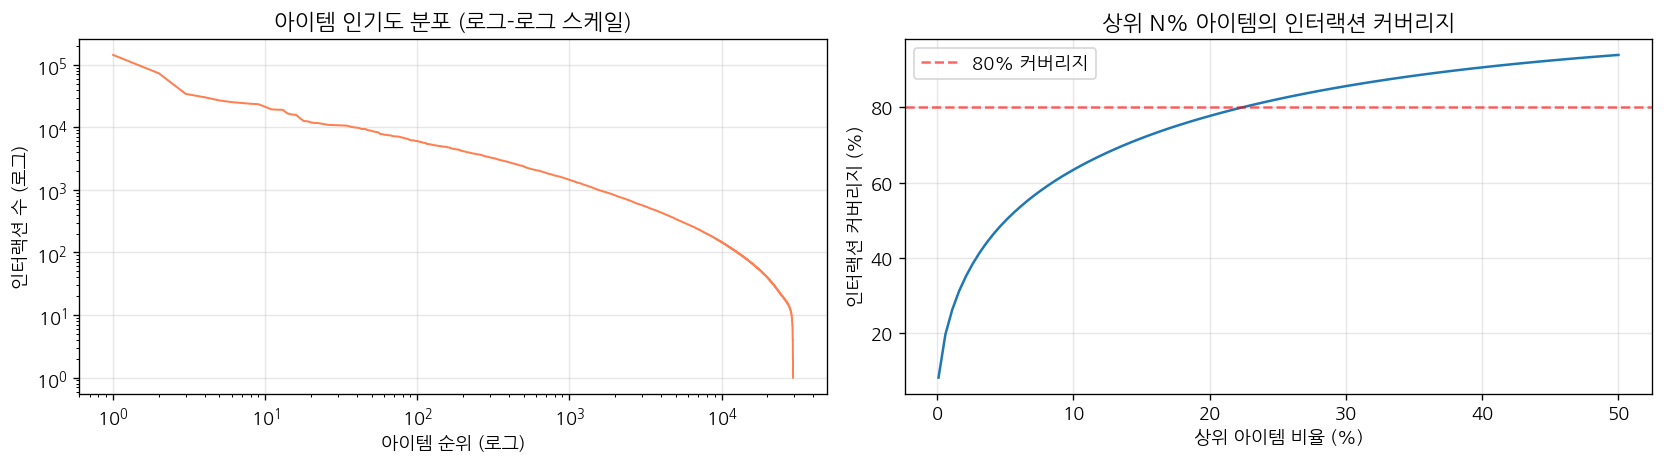

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 로그-로그 롱테일 분포
rank = np.arange(1, len(item_cnt)+1)
axes[0].loglog(rank, item_cnt.values, linewidth=1.2, color='coral')
axes[0].set_title('아이템 인기도 분포 (로그-로그 스케일)')
axes[0].set_xlabel('아이템 순위 (로그)')
axes[0].set_ylabel('인터랙션 수 (로그)')
axes[0].grid(True, alpha=0.3)

# 상위 N% 아이템의 인터랙션 커버리지
top_pcts = np.linspace(0.001, 0.5, 100)
coverages = [item_cnt.head(int(n_items*p)).sum() / len(df) for p in top_pcts]
axes[1].plot(top_pcts*100, np.array(coverages)*100, linewidth=1.5)
axes[1].axhline(80, color='red', linestyle='--', alpha=0.6, label='80% 커버리지')
axes[1].set_title('상위 N% 아이템의 인터랙션 커버리지')
axes[1].set_xlabel('상위 아이템 비율 (%)')
axes[1].set_ylabel('인터랙션 커버리지 (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5-1. 세션별 `event_type` 분포

세션(`user_session`) 단위로 각 이벤트 타입 건수·비중을 보면, 한 세션 안에서 조회·장바구니·구매 등이 어떻게 섞이는지 파악할 수 있습니다.

=== 전체 행 기준 event_type 비율 ===
  view: 99.78%
  cart: 0.20%
  purchase: 0.02%

=== 세션 내 비중(%) — 타입별 요약 (세션마다 합계 100%) ===
event_type         cart     purchase         view
count       2889552.000  2889552.000  2889552.000
mean              0.386        0.062       99.552
std               5.841        2.460        6.336
min               0.000        0.000        0.000
25%               0.000        0.000      100.000
50%               0.000        0.000      100.000
75%               0.000        0.000      100.000
max             100.000      100.000      100.000

=== 세션별 지배 event_type (해당 세션에서 건수가 가장 많은 타입) ===
  view: 2,876,069 세션 (99.53%)
  cart: 11,686 세션 (0.40%)
  purchase: 1,797 세션 (0.06%)

단일 event_type만 있는 세션: 2,882,658 (99.76%)


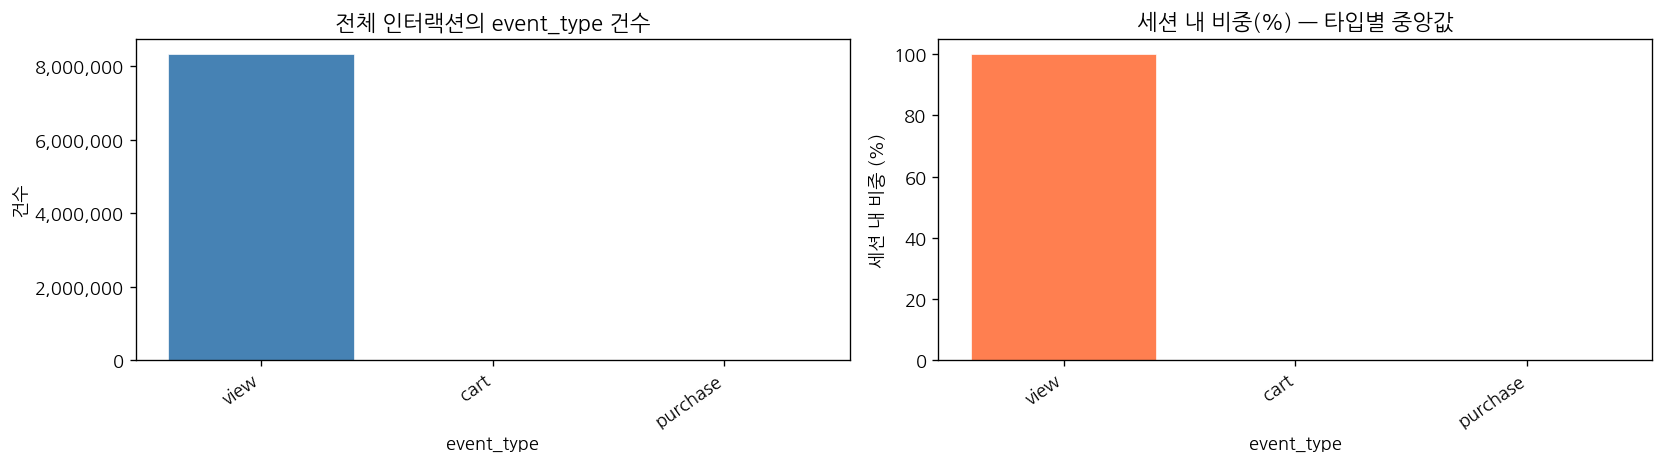

In [15]:
# 세션별 event_type 분포 (건수 · 세션 내 비중 · 지배 타입)
sess_et_cnt = df.groupby(['user_session', 'event_type'], observed=False).size().unstack(fill_value=0)
sess_et_pct = sess_et_cnt.div(sess_et_cnt.sum(axis=1), axis=0)

et_order = df['event_type'].value_counts().index.tolist()

print('=== 전체 행 기준 event_type 비율 ===')
_global = df['event_type'].value_counts(normalize=True).reindex(et_order).dropna()
for et, p in _global.items():
    print(f'  {et}: {p*100:.2f}%')

print('\n=== 세션 내 비중(%) — 타입별 요약 (세션마다 합계 100%) ===')
print((sess_et_pct * 100).describe().round(3).to_string())

dominant = sess_et_cnt.idxmax(axis=1)
print('\n=== 세션별 지배 event_type (해당 세션에서 건수가 가장 많은 타입) ===')
_dom = dominant.value_counts().reindex(et_order).fillna(0).astype(int)
for et, n in _dom.items():
    print(f'  {et}: {n:,} 세션 ({n / len(dominant) * 100:.2f}%)')

pure_sessions = (sess_et_cnt.gt(0).sum(axis=1) == 1).sum()
print(f'\n단일 event_type만 있는 세션: {pure_sessions:,} ({pure_sessions / len(sess_et_cnt) * 100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vc = df['event_type'].value_counts().reindex(et_order).dropna()
axes[0].bar(range(len(vc)), vc.values, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(vc.index, rotation=35, ha='right')
axes[0].set_title('전체 인터랙션의 event_type 건수')
axes[0].set_xlabel('event_type')
axes[0].set_ylabel('건수')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

median_pct = (sess_et_pct[et_order] * 100).median().reindex(et_order).dropna()
axes[1].bar(range(len(median_pct)), median_pct.values, color='coral', edgecolor='white', linewidth=0.4)
axes[1].set_xticks(range(len(median_pct)))
axes[1].set_xticklabels(median_pct.index, rotation=35, ha='right')
axes[1].set_title('세션 내 비중(%) — 타입별 중앙값')
axes[1].set_xlabel('event_type')
axes[1].set_ylabel('세션 내 비중 (%)')

plt.tight_layout()
plt.show()


## 6. 아이템 반복도 분석 (전체 이벤트 기준)

> **정의**: 유저당 **view + cart + purchase** 모든 행에서, 같은 `item_id`가 여러 번 등장하는 비율 \(1 - \frac{\text{고유 item 수}}{\text{전체 행 수}}\)의 평균. **구매(purchase)만의 재구매율이 아님** (view 비중이 크면 조회 반복의 영향이 큼).
>
> **모델 선택 참고**: 이 값이 높으면 **동일 아이템 재노출·빈도** 신호로 SAFERec / TIFU-KNN 등을 검토 (PLAN에서는 view 빈도 피처로 재해석).

In [16]:
# 유저별 아이템 반복도 (전 이벤트: view+cart+purchase, purchase-only 아님)
def repeat_rate(group):
    total = len(group)
    unique = group['item_id'].nunique()
    return 1 - unique / total if total > 1 else 0.0

repeat_per_user = df.groupby('user_id').apply(repeat_rate)
global_repeat_rate = repeat_per_user.mean()

print(f'전체 평균 아이템 반복도    : {global_repeat_rate*100:.2f}%  (전 이벤트 기준, 구매만 아님)')
print(f'반복도 > 0 인 유저 비율      : {(repeat_per_user > 0).mean()*100:.1f}%')
print(f'반복도 > 50% 유저 비율       : {(repeat_per_user > 0.5).mean()*100:.1f}%')
print()

if global_repeat_rate > 0.20:
    print(f'[권고] 아이템 반복도 {global_repeat_rate*100:.1f}% > 20% → SAFERec, TIFU-KNN 우선 실험')
elif global_repeat_rate > 0.10:
    print(f'[권고] 아이템 반복도 {global_repeat_rate*100:.1f}% (10~20%) → TIFU-KNN 앙상블 요소로 활용')
else:
    print(f'[권고] 아이템 반복도 {global_repeat_rate*100:.1f}% < 10% → 순수 순차 모델(SASRec/BSARec) 우선')

전체 평균 아이템 반복도    : 14.63%  (전 이벤트 기준, 구매만 아님)
반복도 > 0 인 유저 비율      : 47.3%
반복도 > 50% 유저 비율       : 6.5%

[권고] 아이템 반복도 14.6% (10~20%) → TIFU-KNN 앙상블 요소로 활용


2회 이상 상호작용 (user, item) 쌍 수 : 1,090,201
전체 (user, item) 쌍 대비            : 18.34%

상호작용 횟수별 분포 (2회 이상 쌍):
2     647136
3     205170
4      92156
5      49328
6      29101
7      18415
8      12512
9       8543
10      6136
11      4360


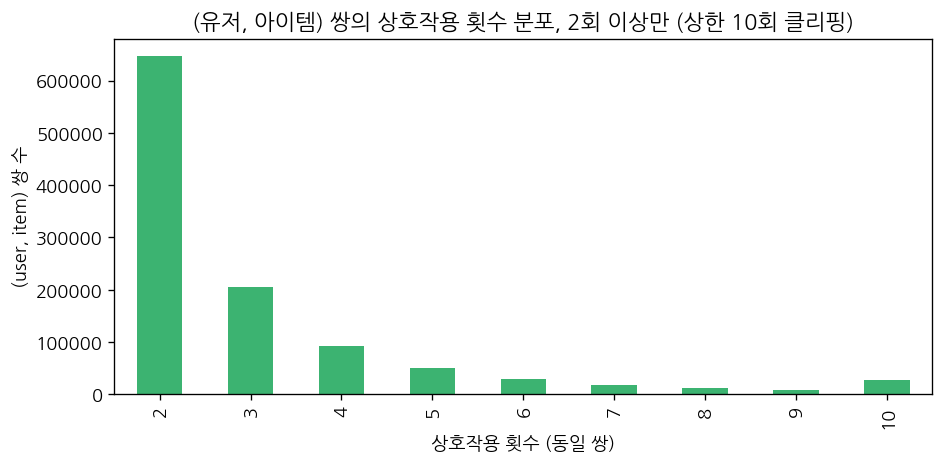

In [17]:
# 유저-아이템 쌍이 전 이벤트(view+cart+purchase) 기준 2회 이상인 경우의 횟수 분포
user_item_cnt = df.groupby(['user_id', 'item_id']).size()
repeat_counts = user_item_cnt[user_item_cnt > 1]

print(f'2회 이상 상호작용 (user, item) 쌍 수 : {len(repeat_counts):,}')
print(f'전체 (user, item) 쌍 대비            : {len(repeat_counts)/len(user_item_cnt)*100:.2f}%')
print()
print('상호작용 횟수별 분포 (2회 이상 쌍):')
print(repeat_counts.value_counts().head(10).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
repeat_counts.clip(upper=10).value_counts().sort_index().plot(kind='bar', ax=ax, color='mediumseagreen')
ax.set_title('(유저, 아이템) 쌍의 상호작용 횟수 분포, 2회 이상만 (상한 10회 클리핑)')
ax.set_xlabel('상호작용 횟수 (동일 쌍)')
ax.set_ylabel('(user, item) 쌍 수')
plt.tight_layout()
plt.show()

In [42]:
df['event_time'] = pd.to_datetime(df['event_time'], utc=True)

# ① event_type=purchase 필터 시 반복 구매율 재계산
if 'purchase' in df['event_type'].values:
    purchase_df = df[df['event_type'] == 'purchase']
    repeat_rate = purchase_df.groupby('user_id').apply(
        lambda g: 1 - g['item_id'].nunique() / len(g) if len(g) > 1 else 0
    ).mean()
    print(f"purchase 기준 반복 구매율: {repeat_rate*100:.2f}%")

purchase 기준 반복 구매율: 3.76%


## 7. 연속 이벤트 간격(Time Gap) 분석

> **모델 선택 기준**: 시간 간격 분산이 클 경우 → TiSASRec 필수

In [33]:
df_sorted = df.sort_values(['user_id', 'event_time']).copy()
df_sorted['time_gap_sec'] = (
    df_sorted.groupby('user_id')['event_time']
    .diff()
    .dt.total_seconds()
)
df_sorted['time_gap_hour'] = df_sorted['time_gap_sec'] / 3600
df_sorted['time_gap_day']  = df_sorted['time_gap_sec'] / 86400

gaps = df_sorted['time_gap_day'].dropna()
print('=== 연속 이벤트 간격 통계 (일 단위) ===')
print(gaps.describe(percentiles=[.25, .5, .75, .90, .95, .99]).to_string())
print()
cv = gaps.std() / gaps.mean()
print(f'변동계수(CV): {cv:.3f}')
if cv > 1.0:
    print('[권고] 시간 간격 변동성 높음 → TiSASRec 필수 적용')
else:
    print('[권고] 시간 간격 변동성 보통 → TiSASRec 실험, 효과 미지수')

=== 연속 이벤트 간격 통계 (일 단위) ===
count    7.712054e+06
mean     1.312800e+00
std      5.411470e+00
min      0.000000e+00
25%      3.240741e-04
50%      8.564815e-04
75%      8.587963e-03
90%      2.640428e+00
95%      7.704923e+00
99%      2.607964e+01
max      1.194353e+02

변동계수(CV): 4.122
[권고] 시간 간격 변동성 높음 → TiSASRec 필수 적용


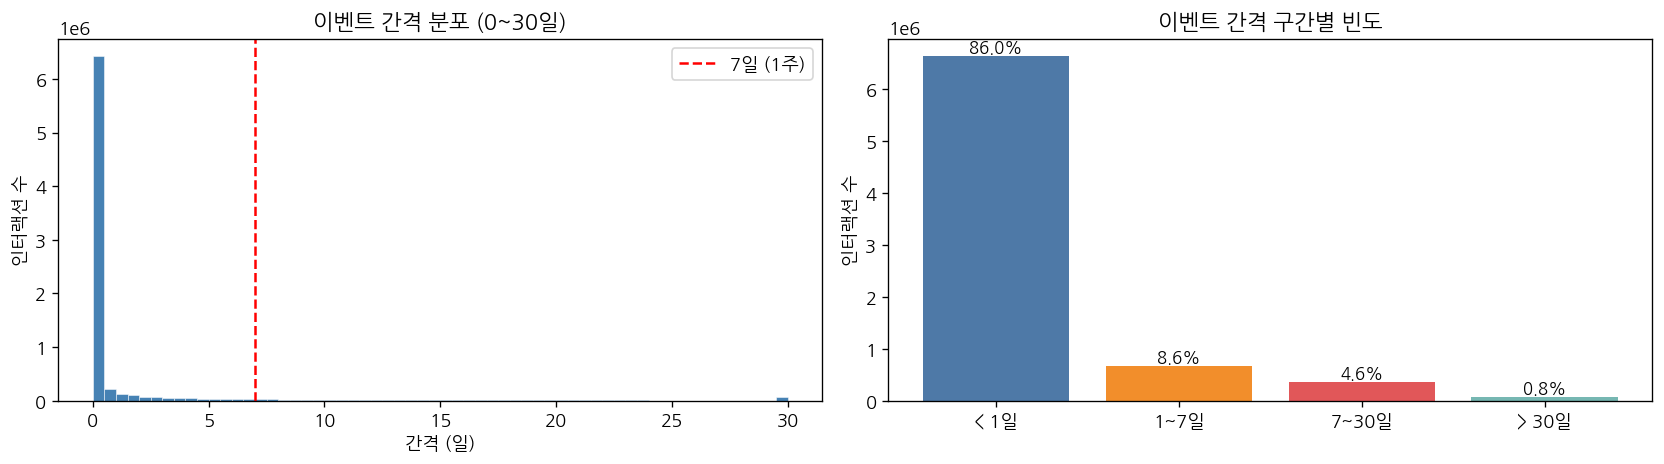

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 구매 간격 히스토그램 (0~30일)
gaps_clipped = gaps.clip(0, 30)
axes[0].hist(gaps_clipped, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(7, color='red', linestyle='--', label='7일 (1주)')
axes[0].set_title('이벤트 간격 분포 (0~30일)')
axes[0].set_xlabel('간격 (일)')
axes[0].set_ylabel('인터랙션 수')
axes[0].legend()

# 구간별 비율 (1일 미만 / 1~7일 / 7~30일 / 30일 초과)
bins_label = ['< 1일', '1~7일', '7~30일', '> 30일']
bins_count = [
    (gaps < 1).sum(),
    ((gaps >= 1) & (gaps < 7)).sum(),
    ((gaps >= 7) & (gaps < 30)).sum(),
    (gaps >= 30).sum(),
]
axes[1].bar(bins_label, bins_count, color=['#4e79a7','#f28e2b','#e15759','#76b7b2'])
axes[1].set_title('이벤트 간격 구간별 빈도')
axes[1].set_ylabel('인터랙션 수')
for i, v in enumerate(bins_count):
    axes[1].text(i, v + max(bins_count)*0.01, f'{v/sum(bins_count)*100:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

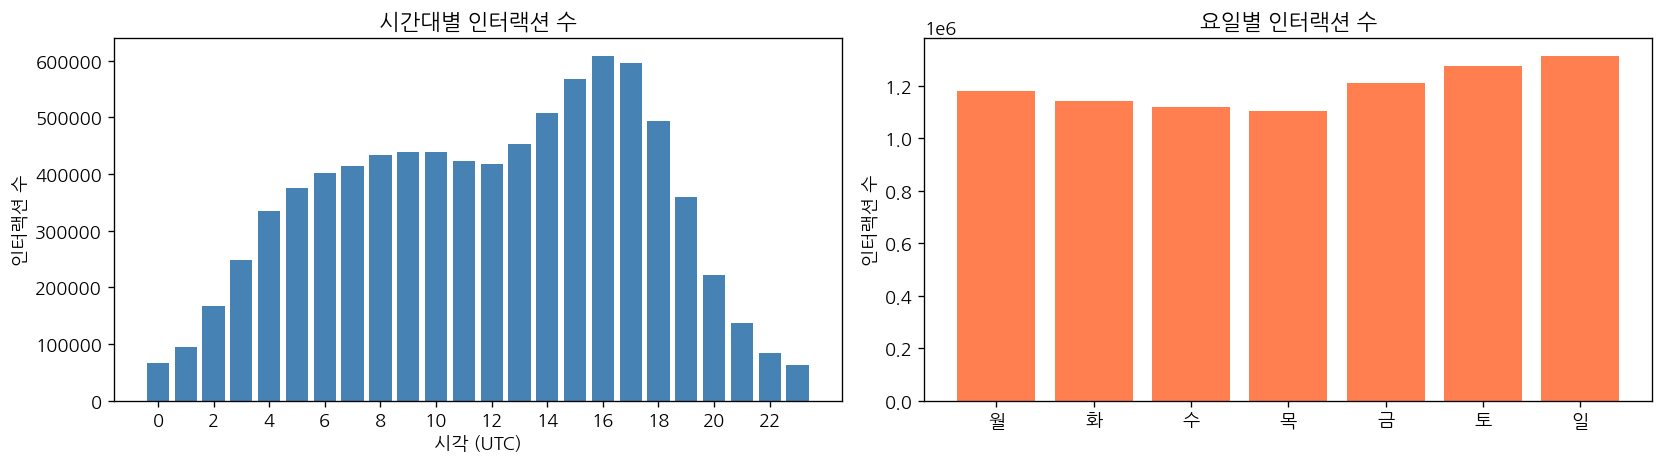

In [ ]:
# 요일·시간대별 인터렉션 패턴
df['hour']    = df['event_time'].dt.hour
df['weekday'] = df['event_time'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hour_cnt = df.groupby('hour').size()
axes[0].bar(hour_cnt.index, hour_cnt.values, color='steelblue')
axes[0].set_title('시간대별 인터랙션 수')
axes[0].set_xlabel('시각 (UTC)')
axes[0].set_ylabel('인터랙션 수')
axes[0].set_xticks(range(0, 24, 2))

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_cnt = df.groupby('weekday').size().reindex(weekday_order)
axes[1].bar(range(7), weekday_cnt.values, color='coral')
axes[1].set_title('요일별 인터랙션 수')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['월','화','수','목','금','토','일'])
axes[1].set_ylabel('인터랙션 수'션

plt.tight_layout()
plt.show()

=== Feb 27~29 purchase spike (일별 건수) ===
event_type   view  cart  purchase
date                             
2020-02-27   6533     0       668
2020-02-28  33819    15       410
2020-02-29  39383    20       359

2월 1일~26일 purchase 일별 중앙값 : 4
Feb 27 purchase / 중앙값 배율     : 167.0x
Feb 27~29 purchase 합계             : 1,437
전체 기간 purchase 합계 대비 비율   : 69.2%

=== 직전 7일(2/20~2/26) 일평균 vs 스파이크 3일 일평균 ===
            직전7일_일평균  스파이크3일_일평균  배율(스파이크/직전7일)
event_type                                     
view         63520.0     26578.3            0.4
cart            50.4        11.7            0.2
purchase         1.3       479.0          372.6


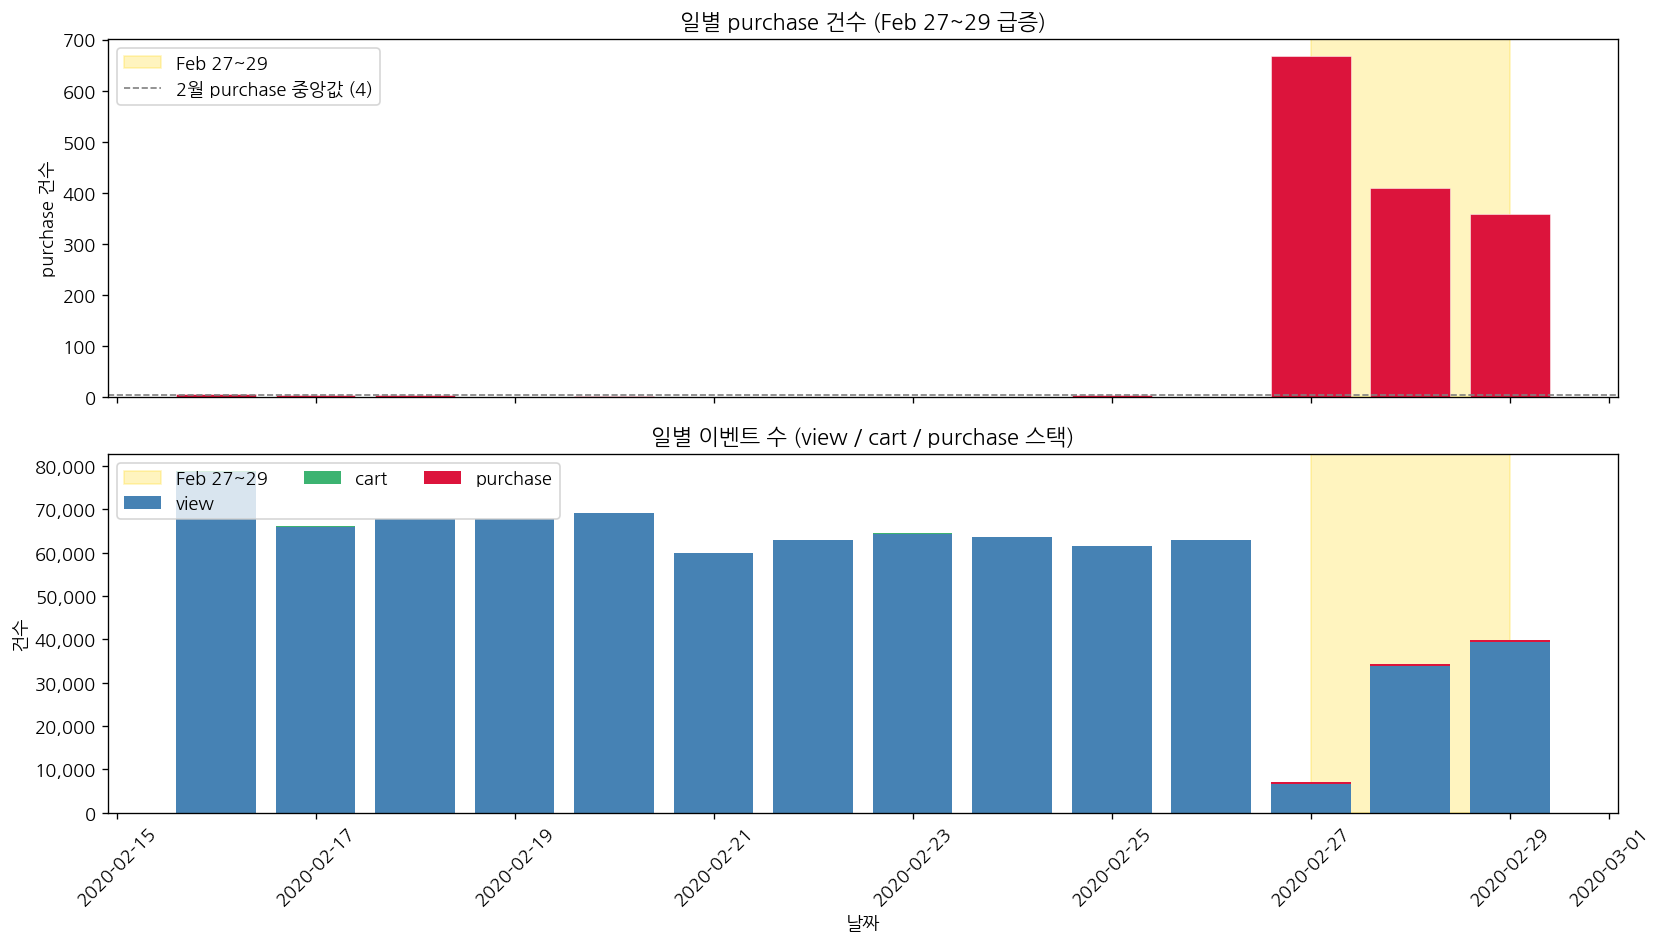


=== 일별 purchase 비중 (%) ===
event_type  purchase   view  cart  purchase_share_pct
date                                                 
2020-02-16         6  78765    79                0.01
2020-02-17         4  66066    56                0.01
2020-02-18         5  67708    58                0.01
2020-02-19         1  67697    60                0.00
2020-02-20         2  69197    59                0.00
2020-02-21         1  59851    53                0.00
2020-02-22         0  62966    58                0.00
2020-02-23         0  64439    43                0.00
2020-02-24         1  63666    42                0.00
2020-02-25         4  61514    58                0.01
2020-02-26         1  63007    40                0.00
2020-02-27       668   6533     0                9.28
2020-02-28       410  33819    15                1.20
2020-02-29       359  39383    20                0.90


In [32]:
# Feb 27~29 purchase spike 확인
SPIKE_START = pd.Timestamp('2020-02-27', tz='UTC').date()
SPIKE_END   = pd.Timestamp('2020-02-29', tz='UTC').date()
BASELINE_END = SPIKE_START - pd.Timedelta(days=1)

if 'date' not in df.columns:
    df['date'] = df['event_time'].dt.date

daily_et = (
    df.groupby(['date', 'event_type'], observed=True)
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
for col in ['view', 'cart', 'purchase']:
    if col not in daily_et.columns:
        daily_et[col] = 0
daily_et = daily_et[['view', 'cart', 'purchase']]

# 말미 14일 + 스파이크 구간 강조용
plot_start = pd.Timestamp('2020-02-16').date()
plot_df = daily_et.loc[daily_et.index >= plot_start].copy()

baseline = daily_et.loc[
    (daily_et.index >= pd.Timestamp('2020-02-01').date()) & (daily_et.index <= BASELINE_END)
]
baseline_purchase = baseline['purchase'].median()
baseline_view = baseline['view'].median()

spike_mask = (plot_df.index >= SPIKE_START) & (plot_df.index <= SPIKE_END)
spike_purchase = plot_df.loc[spike_mask, 'purchase']

print('=== Feb 27~29 purchase spike (일별 건수) ===')
print(plot_df.loc[spike_mask].to_string())
print()
print(f'2월 1일~26일 purchase 일별 중앙값 : {baseline_purchase:.0f}')
print(f'Feb 27 purchase / 중앙값 배율     : {plot_df.loc[SPIKE_START, "purchase"] / max(baseline_purchase, 1):.1f}x')
print(f'Feb 27~29 purchase 합계             : {spike_purchase.sum():,}')
print(f'전체 기간 purchase 합계 대비 비율   : {spike_purchase.sum() / df.loc[df["event_type"]=="purchase"].shape[0] * 100:.1f}%')
print()

# 스파이크 vs 직전 7일 평균
prior7 = daily_et.loc[
    (daily_et.index >= pd.Timestamp('2020-02-20').date()) & (daily_et.index < SPIKE_START)
]
print('=== 직전 7일(2/20~2/26) 일평균 vs 스파이크 3일 일평균 ===')
cmp = pd.DataFrame({
    '직전7일_일평균': prior7.mean(),
    '스파이크3일_일평균': plot_df.loc[spike_mask].mean(),
})
cmp['배율(스파이크/직전7일)'] = cmp['스파이크3일_일평균'] / cmp['직전7일_일평균'].replace(0, np.nan)
print(cmp.round(1).to_string())

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

x = pd.to_datetime(plot_df.index)
for ax in axes:
    ax.axvspan(SPIKE_START, SPIKE_END, color='gold', alpha=0.25, label='Feb 27~29')

# (1) purchase만 — 스파이크가 가장 뚜렷
axes[0].bar(x, plot_df['purchase'], width=0.8, color='crimson', edgecolor='white', linewidth=0.3)
axes[0].axhline(baseline_purchase, color='gray', linestyle='--', linewidth=1,
                label=f'2월 purchase 중앙값 ({baseline_purchase:.0f})')
axes[0].set_title('일별 purchase 건수 (Feb 27~29 급증)')
axes[0].set_ylabel('purchase 건수')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axes[0].legend(loc='upper left')

# (2) event_type별 스택 — view/cart 맥락
bottom = np.zeros(len(plot_df))
colors = {'view': 'steelblue', 'cart': 'mediumseagreen', 'purchase': 'crimson'}
for et in ['view', 'cart', 'purchase']:
    axes[1].bar(x, plot_df[et], width=0.8, bottom=bottom, label=et, color=colors[et], edgecolor='none')
    bottom += plot_df[et].values
axes[1].set_title('일별 이벤트 수 (view / cart / purchase 스택)')
axes[1].set_xlabel('날짜')
axes[1].set_ylabel('건수')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axes[1].legend(loc='upper left', ncol=3)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# purchase 비중(해당 일 전체 이벤트 중)
plot_df['purchase_share_pct'] = plot_df['purchase'] / plot_df.sum(axis=1) * 100
print('\n=== 일별 purchase 비중 (%) ===')
print(plot_df.loc[plot_start:, ['purchase', 'view', 'cart', 'purchase_share_pct']].round(2).to_string())


## 8. 행동 전환 (view→cart→purchase) 및 장바구니 상품 특성

유저·동일 `item_id` 기준으로 **이전 이벤트 시각보다 뒤에** 다음 타입이 오면 전환으로 집계합니다.

=== 유저·item_id·시간순 전환 (t_to > t_from) ===
view → cart: 45,665건 (from view 행 8,331,873건 대비 0.548%)
view → purchase: 6,116건 (from view 행 8,331,873건 대비 0.073%)
cart → purchase: 130건 (from cart 행 16,362건 대비 0.795%)

=== 유저·item 쌍 기준 퍼널 (첫 발생 시각) ===
view 있는 쌍              : 5,936,433
  → 이후 cart (view 이후)  : 6,354 (0.11%)
  → 이후 purchase (view 이후): 1,035 (0.02%)
cart 있는 쌍              : 13,276
  → 이후 purchase (cart 이후): 59

=== cart 경험 상품 vs view만 상품 (아이템 단위) ===

[cart 경험] n=3,854
  가격 중앙값: 67.70
  view 중앙값(건수/아이템): 497

[view만] n=25,648
  가격 중앙값: 62.81
  view 중앙값(건수/아이템): 62

=== cart 경험 상품 — cat_l2 상위 10 ===
cat_l2
shoes        2441
scarf         322
shirt         227
costume       223
underwear     195
shorts         97
trousers       80
tshirt         76
jeans          69
pajamas        31

=== view만 상품 — cat_l2 상위 10 ===
cat_l2
shoes        14135
shirt         2759
costume       1709
underwear     1668
scarf         1059
jeans          678
tshirt         594
trousers       589
jumper

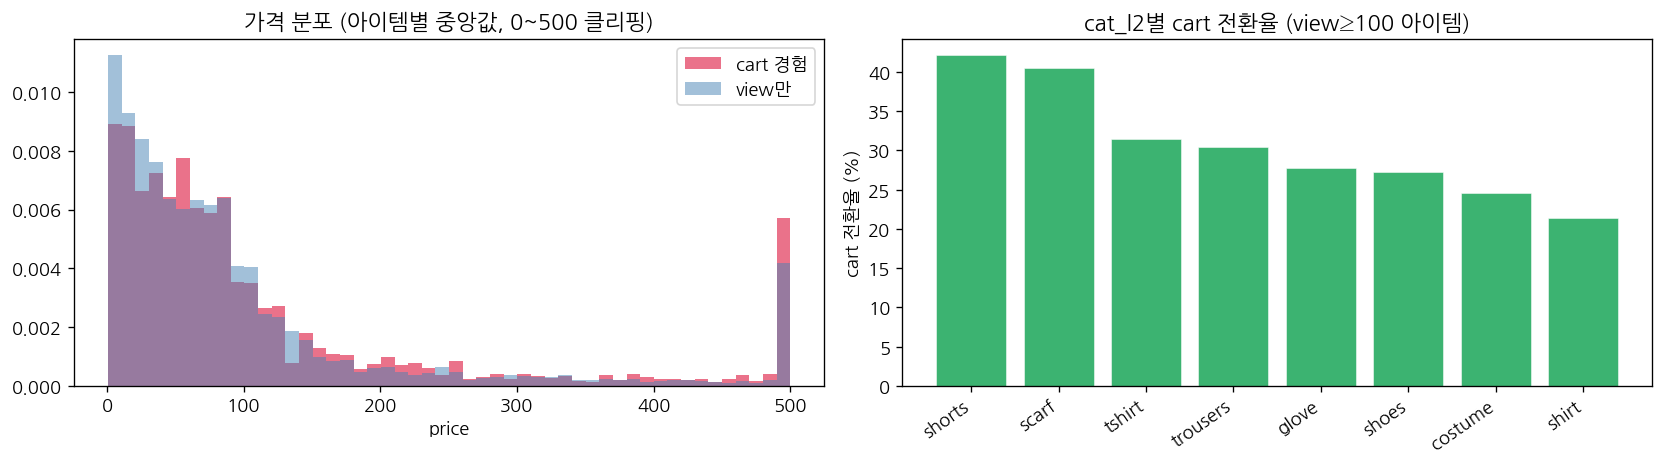

In [43]:
# ── 8-1. view→cart, view→purchase, cart→purchase (유저·item_id·시간순) ──
def count_temporal_pairs(df, et_from, et_to, label):
    a = df.loc[df['event_type'] == et_from, ['user_id', 'item_id', 'event_time']].rename(columns={'event_time': 't_from'})
    b = df.loc[df['event_type'] == et_to, ['user_id', 'item_id', 'event_time']].rename(columns={'event_time': 't_to'})
    if a.empty or b.empty:
        print(f'{label}: 데이터 없음')
        return 0, 0
    m = a.merge(b, on=['user_id', 'item_id'], how='inner')
    m = m[m['t_to'] > m['t_from']]
    n_pairs = len(m)
    n_from = len(a)
    rate = n_pairs / n_from * 100 if n_from else 0
    print(f'{label}: {n_pairs:,}건 (from {et_from} 행 {n_from:,}건 대비 {rate:.3f}%)')
    return n_pairs, n_from

print('=== 유저·item_id·시간순 전환 (t_to > t_from) ===')
count_temporal_pairs(df, 'view', 'cart', 'view → cart')
count_temporal_pairs(df, 'view', 'purchase', 'view → purchase')
count_temporal_pairs(df, 'cart', 'purchase', 'cart → purchase')
print()

first_et = (
    df.sort_values('event_time')
    .groupby(['user_id', 'item_id', 'event_type'], observed=True)
    .agg(t=('event_time', 'min'))
    .reset_index()
)
pivot = first_et.pivot_table(index=['user_id', 'item_id'], columns='event_type', values='t', aggfunc='min')
for c in ['view', 'cart', 'purchase']:
    if c not in pivot.columns:
        pivot[c] = pd.NaT

has_view = pivot['view'].notna()
has_cart = pivot['cart'].notna() & (pivot['cart'] > pivot['view'])
has_pur = pivot['purchase'].notna() & (pivot['purchase'] > pivot['view'])
has_cart_pur = pivot['purchase'].notna() & pivot['cart'].notna() & (pivot['purchase'] > pivot['cart'])

print('=== 유저·item 쌍 기준 퍼널 (첫 발생 시각) ===')
print(f'view 있는 쌍              : {has_view.sum():,}')
print(f'  → 이후 cart (view 이후)  : {has_cart.sum():,} ({has_cart.sum()/has_view.sum()*100:.2f}%)')
print(f'  → 이후 purchase (view 이후): {has_pur.sum():,} ({has_pur.sum()/has_view.sum()*100:.2f}%)')
print(f'cart 있는 쌍              : {pivot["cart"].notna().sum():,}')
print(f'  → 이후 purchase (cart 이후): {has_cart_pur.sum():,}')
print()

if 'cat_l2' not in df.columns:
    df['cat_l2'] = df['category_code'].str.split('.').str[1]

item_meta = df.groupby('item_id', observed=True).agg(
    price_med=('price', 'median'),
    cat_l2=('cat_l2', lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0]),
    brand=('brand', lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0]),
    n_view=('event_type', lambda s: (s == 'view').sum()),
    n_cart=('event_type', lambda s: (s == 'cart').sum()),
    n_purchase=('event_type', lambda s: (s == 'purchase').sum()),
).reset_index()

item_meta['ever_cart'] = item_meta['n_cart'] > 0
item_meta['ever_view'] = item_meta['n_view'] > 0
cart_items = item_meta[item_meta['ever_cart']]
view_only = item_meta[item_meta['ever_view'] & ~item_meta['ever_cart']]

print('=== cart 경험 상품 vs view만 상품 (아이템 단위) ===')
for name, sub in [('cart 경험', cart_items), ('view만', view_only)]:
    print(f'\n[{name}] n={len(sub):,}')
    print(f'  가격 중앙값: {sub["price_med"].median():.2f}')
    print(f'  view 중앙값(건수/아이템): {sub["n_view"].median():.0f}')

print('\n=== cart 경험 상품 — cat_l2 상위 10 ===')
print(cart_items['cat_l2'].value_counts().head(10).to_string())
print('\n=== view만 상품 — cat_l2 상위 10 ===')
print(view_only['cat_l2'].value_counts().head(10).to_string())

cat_conv = (
    item_meta[item_meta['n_view'] >= 100]
    .groupby('cat_l2', observed=True)
    .agg(n_items=('item_id', 'count'), cart_rate=('ever_cart', 'mean'), price_med=('price_med', 'median'))
    .sort_values('cart_rate', ascending=False)
)
print('\n=== cat_l2별 cart 전환율 (view≥100인 아이템만, 상위 10) ===')
print(cat_conv.head(10).round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(cart_items['price_med'].clip(0, 500), bins=50, alpha=0.6, label='cart 경험', color='crimson', density=True)
axes[0].hist(view_only['price_med'].clip(0, 500), bins=50, alpha=0.5, label='view만', color='steelblue', density=True)
axes[0].set_title('가격 분포 (아이템별 중앙값, 0~500 클리핑)')
axes[0].set_xlabel('price')
axes[0].legend()

top_cats = cat_conv.head(8).index.tolist()
x = np.arange(len(top_cats))
axes[1].bar(x, cat_conv.loc[top_cats, 'cart_rate'] * 100, color='mediumseagreen', edgecolor='white', linewidth=0.3)
axes[1].set_xticks(x)
axes[1].set_xticklabels(top_cats, rotation=35, ha='right')
axes[1].set_ylabel('cart 전환율 (%)')
axes[1].set_title('cat_l2별 cart 전환율 (view≥100 아이템)')
plt.tight_layout()
plt.show()


## 9. purchase 시간·요일 패턴

`event_type == 'purchase'` 행만 대상으로 UTC 기준 시각·요일 분포를 봅니다.

purchase 총 건수: 2,076

=== 시간대별 purchase ===
hour
0      15
1      11
2      45
3      80
4     109
5     120
6     159
7     123
8     129
9     143
10    139
11    134
12    120
13    129
14     91
15    125
16     97
17     98
18     68
19     50
20     29
21     32
22     15
23     15

=== 요일별 purchase ===
weekday
Monday        67
Tuesday       60
Wednesday     80
Thursday     792
Friday       505
Saturday     443
Sunday       129

피크 시간대(UTC): 6시 / 피크 요일: Thursday


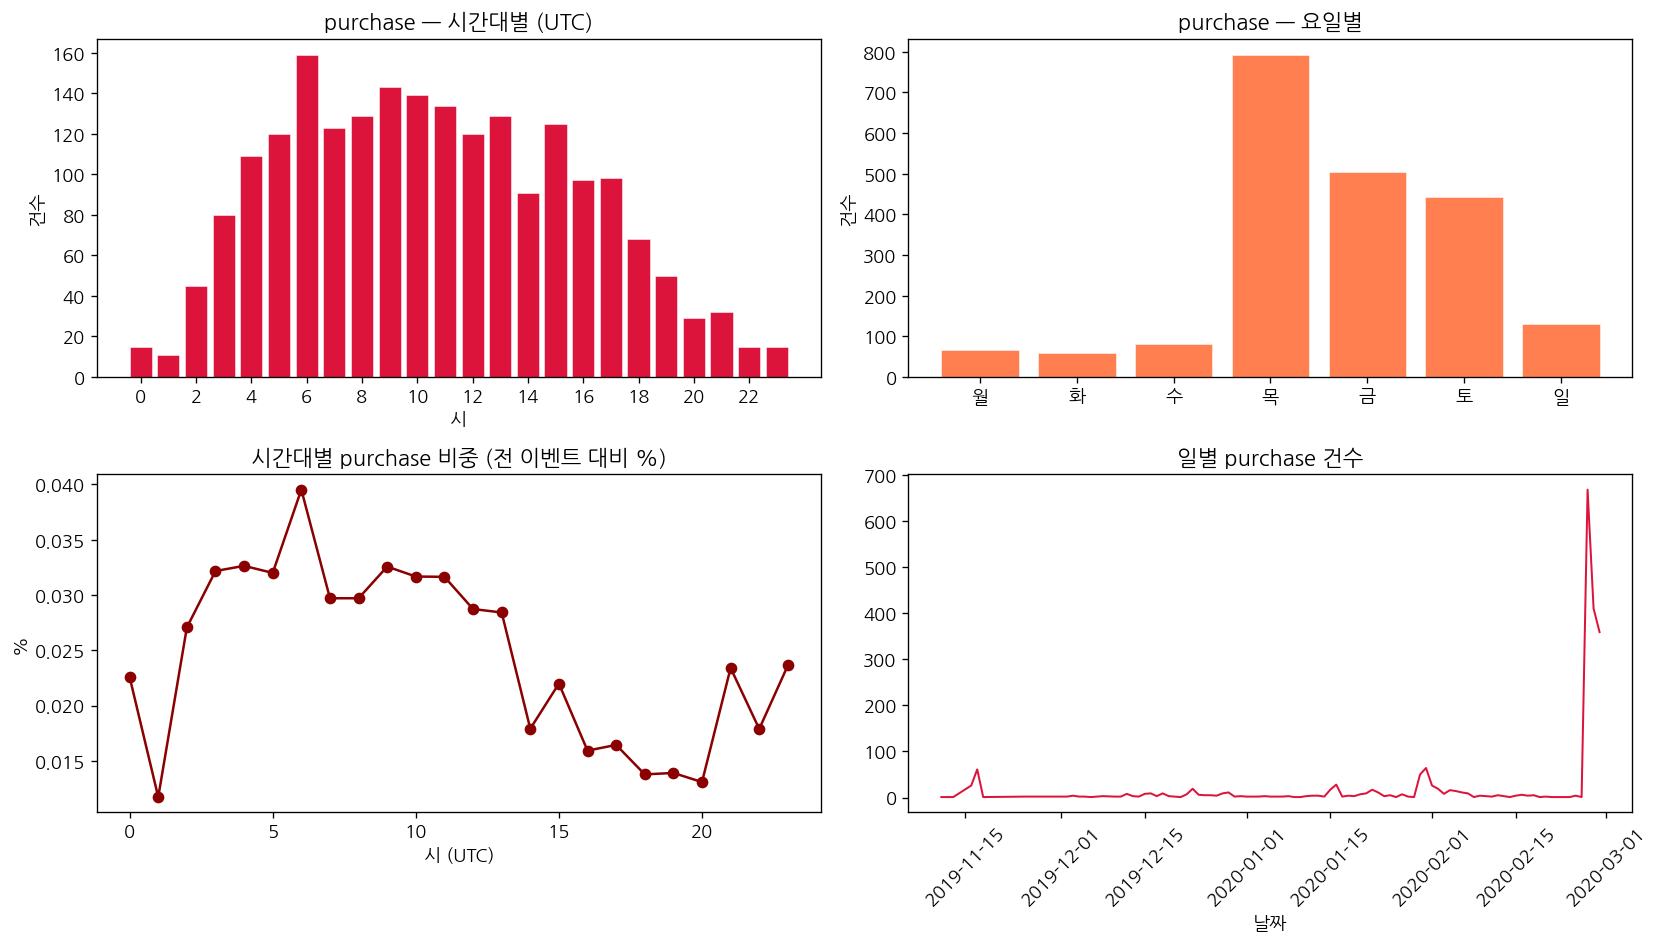

In [46]:
pur = df.loc[df['event_type'] == 'purchase'].copy()
if 'hour' not in df.columns:
    df['hour'] = df['event_time'].dt.hour
if 'weekday' not in df.columns:
    df['weekday'] = df['event_time'].dt.day_name()
pur['hour'] = pur['event_time'].dt.hour
pur['weekday'] = pur['event_time'].dt.day_name()
pur['date'] = pur['event_time'].dt.date

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
wd_ko = ['월', '화', '수', '목', '금', '토', '일']

print(f'purchase 총 건수: {len(pur):,}')
print('\n=== 시간대별 purchase ===')
print(pur.groupby('hour', observed=True).size().to_string())
print('\n=== 요일별 purchase ===')
print(pur.groupby('weekday', observed=True).size().reindex(weekday_order).to_string())

peak_hour = pur.groupby('hour').size().idxmax()
peak_wd   = pur.groupby('weekday').size().reindex(weekday_order).idxmax()
print(f'\n피크 시간대(UTC): {peak_hour}시 / 피크 요일: {peak_wd}')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

hour_cnt = pur.groupby('hour').size().reindex(range(24), fill_value=0)
axes[0, 0].bar(hour_cnt.index, hour_cnt.values, color='crimson', edgecolor='white', linewidth=0.3)
axes[0, 0].set_title('purchase — 시간대별 (UTC)')
axes[0, 0].set_xlabel('시')
axes[0, 0].set_ylabel('건수')
axes[0, 0].set_xticks(range(0, 24, 2))

wd_cnt = pur.groupby('weekday').size().reindex(weekday_order, fill_value=0)
axes[0, 1].bar(range(7), wd_cnt.values, color='coral', edgecolor='white', linewidth=0.3)
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(wd_ko)
axes[0, 1].set_title('purchase — 요일별')
axes[0, 1].set_ylabel('건수')

# 전체 이벤트 대비 purchase 비중 (시간대)
all_hour = df.groupby('hour').size().reindex(range(24), fill_value=0)
pur_share_hour = (hour_cnt / all_hour.replace(0, np.nan) * 100).fillna(0)
axes[1, 0].plot(pur_share_hour.index, pur_share_hour.values, marker='o', color='darkred')
axes[1, 0].set_title('시간대별 purchase 비중 (전 이벤트 대비 %)')
axes[1, 0].set_xlabel('시 (UTC)')
axes[1, 0].set_ylabel('%')

daily_pur = pur.groupby('date').size()
axes[1, 1].plot(pd.to_datetime(daily_pur.index), daily_pur.values, linewidth=1.2, color='crimson')
axes[1, 1].set_title('일별 purchase 건수')
axes[1, 1].set_xlabel('날짜')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

## 10. 인기 카테고리·브랜드

purchase 기준 `cat_l2`·`brand` 빈도와, 전체 이벤트 대비 purchase 비율을 함께 봅니다.

=== purchase — cat_l2 상위 ===
cat_l2
shoes        1487
trousers      164
shirt          87
costume        80
scarf          72
underwear      51
shorts         45
tshirt         40
jeans          19
sock            7
pajamas         6
glove           6
jumper          4
skirt           3
dress           2

=== purchase — brand 상위 (빈도<10 → UNK, 고유 334) ===
brand_mapped
xiaomi      224
sony        180
samsung     112
iqos        101
respect      74
apple        51
defacto      50
glo          43
luminarc     43
lg           40
nika         32
omron        28
starline     28
bq           27
montale      26

=== cat_l2별 purchase 비중 (해당 cat 전체 이벤트 대비 %) 상위 10 ===
cat_l2
trousers    0.109
jacket      0.036
tshirt      0.030
shoes       0.025
shirt       0.025
shorts      0.023
jeans       0.021
belt        0.019
scarf       0.019
costume     0.019


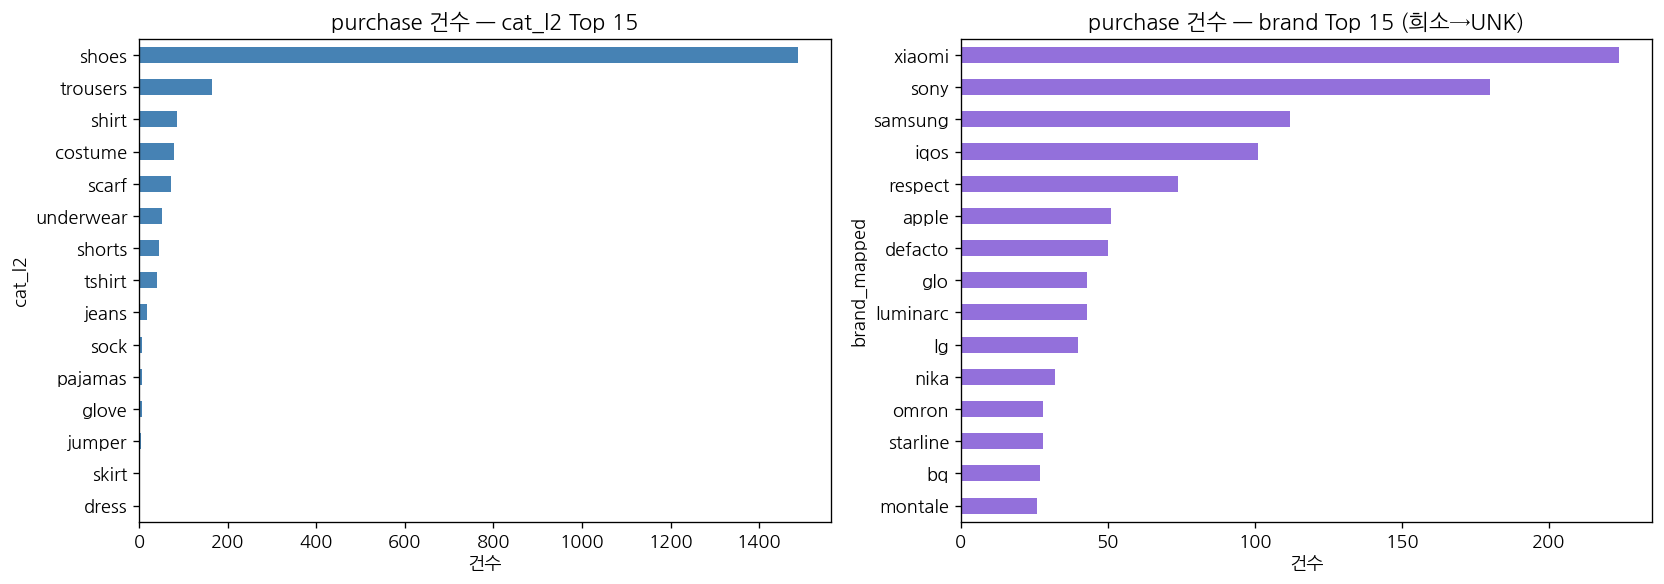

In [47]:
if 'cat_l2' not in df.columns:
  df['cat_l2'] = df['category_code'].str.split('.').str[1]

TOP_N = 15
MIN_BRAND_FREQ = 10

pur = df.loc[df['event_type'] == 'purchase']
brand_freq = df['brand'].value_counts()
rare_brands = set(brand_freq[brand_freq < MIN_BRAND_FREQ].index)
df['brand_mapped'] = df['brand'].where(~df['brand'].isin(rare_brands), other='UNK')

pur_cat = pur['cat_l2'].value_counts()
pur_brand = pur['brand_mapped'].value_counts()

print('=== purchase — cat_l2 상위 ===')
print(pur_cat.head(TOP_N).to_string())
print(f'\n=== purchase — brand 상위 (빈도<{MIN_BRAND_FREQ} → UNK, 고유 {pur["brand_mapped"].nunique():,}) ===')
print(pur_brand.head(TOP_N).to_string())

# 카테고리별 purchase / 전체 이벤트
cat_all = df.groupby('cat_l2', observed=True).size()
cat_pur = pur.groupby('cat_l2', observed=True).size()
cat_pur_rate = (cat_pur / cat_all * 100).sort_values(ascending=False)
print('\n=== cat_l2별 purchase 비중 (해당 cat 전체 이벤트 대비 %) 상위 10 ===')
print(cat_pur_rate.head(10).round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pur_cat.head(TOP_N).iloc[::-1].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title(f'purchase 건수 — cat_l2 Top {TOP_N}')
axes[0].set_xlabel('건수')

pur_brand.head(TOP_N).iloc[::-1].plot(kind='barh', ax=axes[1], color='mediumpurple')
axes[1].set_title(f'purchase 건수 — brand Top {TOP_N} (희소→UNK)')
axes[1].set_xlabel('건수')
plt.tight_layout()
plt.show()

## 11. 구매 가격대 분석

`purchase` 행의 `price` 분포와 cat_l2·brand별 가격 요약입니다.

=== purchase price 요약 ===
count    2076.000000
mean      122.291315
std       152.511697
min         0.950000
10%        17.295000
25%        30.182500
50%        64.240000
75%       131.707500
90%       383.900000
95%       416.200000
99%       664.680000
max      1593.350000

price = 0 건수: 0

=== 가격대별 purchase 건수 ===
price_bin
0-25       297
25-50      573
50-75      249
75-100     279
100-150    189
150-200    114
200-300     84
300-500    242
500-1k      41
1k+          8

=== cat_l2별 purchase 가격 (건수 상위 10) ===
           count  median    mean
cat_l2                          
shoes       1487   79.33  140.17
trousers     164   43.76   52.58
shirt         87   24.69   51.36
costume       80   60.81   87.66
scarf         72   30.71   55.88
underwear     51   58.95  135.49
shorts        45   73.08  187.66
tshirt        40   36.01   70.03
jeans         19   20.57   31.82
sock           7   72.07   83.82


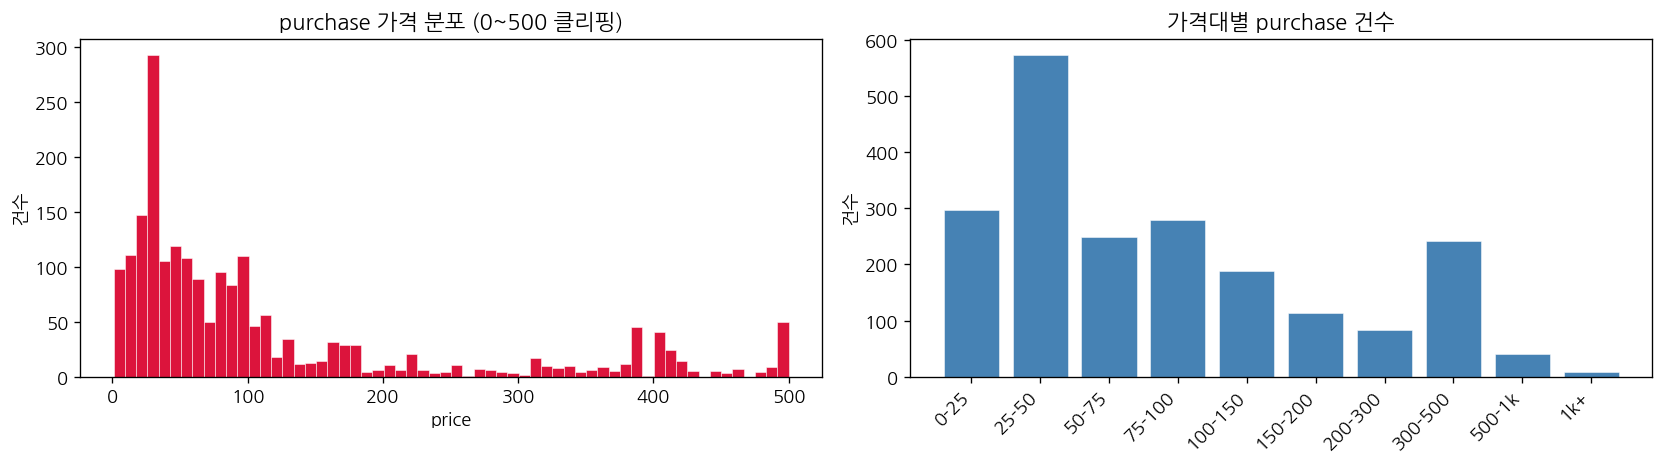

In [48]:
pur = df.loc[df['event_type'] == 'purchase'].copy()
prices = pur['price'].dropna()

print('=== purchase price 요약 ===')
print(prices.describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]).to_string())
print(f'\nprice = 0 건수: {(prices == 0).sum():,}')

bins = [0, 25, 50, 75, 100, 150, 200, 300, 500, 1000, np.inf]
labels = ['0-25', '25-50', '50-75', '75-100', '100-150', '150-200', '200-300', '300-500', '500-1k', '1k+']
pur['price_bin'] = pd.cut(prices, bins=bins, labels=labels, right=False)
bin_cnt = pur['price_bin'].value_counts().sort_index()
print('\n=== 가격대별 purchase 건수 ===')
print(bin_cnt.to_string())

if 'cat_l2' not in pur.columns:
  pur['cat_l2'] = pur['category_code'].str.split('.').str[1]
cat_price = pur.groupby('cat_l2', observed=True)['price'].agg(['count', 'median', 'mean']).sort_values('count', ascending=False)
print('\n=== cat_l2별 purchase 가격 (건수 상위 10) ===')
print(cat_price.head(10).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(prices.clip(0, 500), bins=60, color='crimson', edgecolor='white', linewidth=0.3)
axes[0].set_title('purchase 가격 분포 (0~500 클리핑)')
axes[0].set_xlabel('price')
axes[0].set_ylabel('건수')

axes[1].bar(range(len(bin_cnt)), bin_cnt.values, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].set_xticks(range(len(bin_cnt)))
axes[1].set_xticklabels(bin_cnt.index, rotation=45, ha='right')
axes[1].set_title('가격대별 purchase 건수')
axes[1].set_ylabel('건수')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## 12. 세션 분석

In [22]:
session_cnt = df.groupby('user_session').size()
user_session_cnt = df.groupby('user_id')['user_session'].nunique()

print('=== 세션별 인터랙션 수 통계 ===')
print(session_cnt.describe(percentiles=[.25,.5,.75,.90,.95,.99]).to_string())
print()
print('=== 유저별 세션 수 통계 ===')
print(user_session_cnt.describe(percentiles=[.25,.5,.75,.90,.95,.99]).to_string())

=== 세션별 인터랙션 수 통계 ===
count    2.889552e+06
mean     2.889829e+00
std      4.828436e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      3.000000e+00
90%      6.000000e+00
95%      1.000000e+01
99%      2.000000e+01
max      1.674000e+03

=== 유저별 세션 수 통계 ===
count    638257.000000
mean          4.527255
std          54.010172
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
90%           9.000000
95%          14.000000
99%          30.000000
max       37065.000000


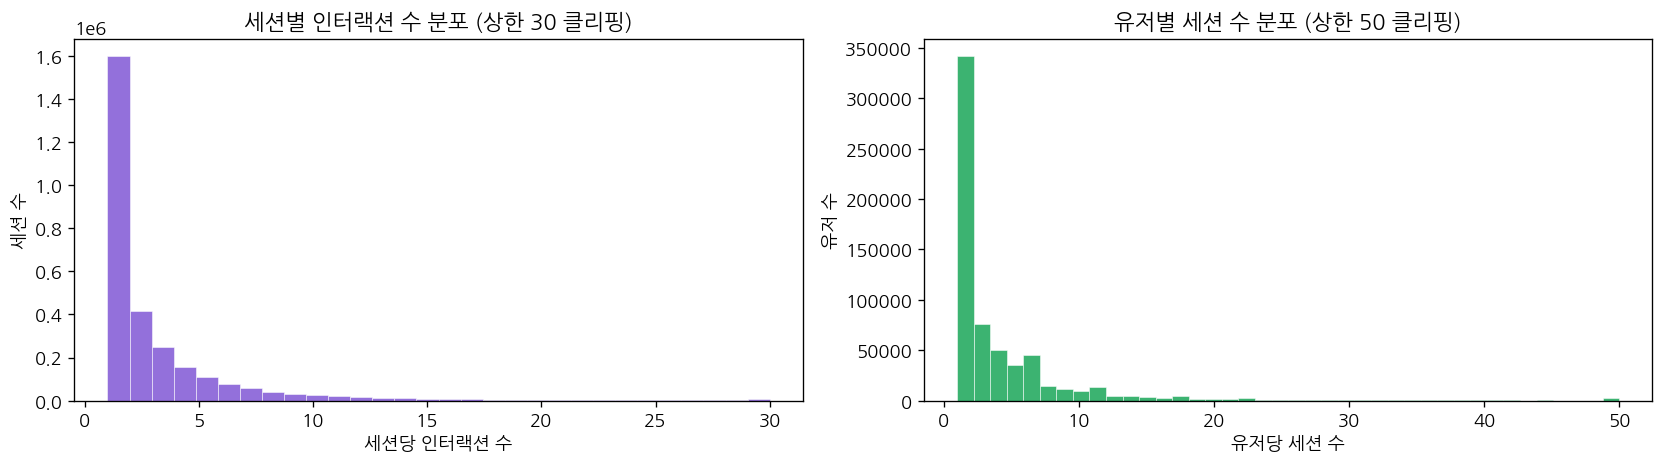

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(session_cnt.clip(upper=30), bins=30, color='mediumpurple', edgecolor='white', linewidth=0.3)
axes[0].set_title('세션별 인터랙션 수 분포 (상한 30 클리핑)')
axes[0].set_xlabel('세션당 인터랙션 수')
axes[0].set_ylabel('세션 수')

axes[1].hist(user_session_cnt.clip(upper=50), bins=40, color='mediumseagreen', edgecolor='white', linewidth=0.3)
axes[1].set_title('유저별 세션 수 분포 (상한 50 클리핑)')
axes[1].set_xlabel('유저당 세션 수')
axes[1].set_ylabel('유저 수')

plt.tight_layout()
plt.show()

## 13. 검증 유저 커버리지 분석

In [24]:
# 캘린더 기반 분할 시 검증 셋 유저 커버리지
train_users = set(df[df['event_time'] < val_cutoff]['user_id'].unique())
val_users   = set(df[df['event_time'] >= val_cutoff]['user_id'].unique())
all_users   = set(df['user_id'].unique())
sub_users   = set(sub.iloc[:, 0].astype(str))

print('=== 캘린더 분할 유저 커버리지 (마지막 7일 기준) ===')
print(f'학습 구간 유저 수  : {len(train_users):,}')
print(f'검증 구간 유저 수  : {len(val_users):,}')
print(f'전체 유저 수       : {len(all_users):,}')
print(f'제출 유저 수       : {len(sub_users):,}')
print()
# 검증 구간에 없는 유저 (폴백 전략 필요)
cold_users = all_users - val_users
print(f'검증 구간 미등장 유저 (폴백 필요): {len(cold_users):,} ({len(cold_users)/len(all_users)*100:.1f}%)')

=== 캘린더 분할 유저 커버리지 (마지막 7일 기준) ===
학습 구간 유저 수  : 623,866
검증 구간 유저 수  : 61,310
전체 유저 수       : 638,257
제출 유저 수       : 638,257

검증 구간 미등장 유저 (폴백 필요): 576,947 (90.4%)


## 14. MAX_ITEM_LIST_LENGTH 결정

In [25]:
# 유저별 고유 아이템 시퀀스 길이 (학습 구간 기준)
train_df = df[df['event_time'] < val_cutoff].copy()
seq_len = train_df.sort_values(['user_id','event_time']).groupby('user_id')['item_id'].count()

for pct in [50, 75, 90, 95, 99]:
    val = int(np.percentile(seq_len, pct))
    coverage = (seq_len <= val).mean()
    print(f'p{pct:2d}: 시퀀스 길이 {val:4d} → 유저 커버리지 {coverage*100:.1f}%')

print()
# 권장값 산출 (90th percentile 기준)
p90 = int(np.percentile(seq_len, 90))
recommended = min(max(p90, 20), 200)  # 최소 20, 최대 200
print(f'[권고] MAX_ITEM_LIST_LENGTH = {recommended}')
print(f'  (90th percentile {p90} 기준, 범위 20~200 클리핑)')

p50: 시퀀스 길이    6 → 유저 커버리지 52.7%
p75: 시퀀스 길이   15 → 유저 커버리지 76.5%
p90: 시퀀스 길이   29 → 유저 커버리지 90.3%
p95: 시퀀스 길이   44 → 유저 커버리지 95.1%
p99: 시퀀스 길이  100 → 유저 커버리지 99.0%

[권고] MAX_ITEM_LIST_LENGTH = 29
  (90th percentile 29 기준, 범위 20~200 클리핑)


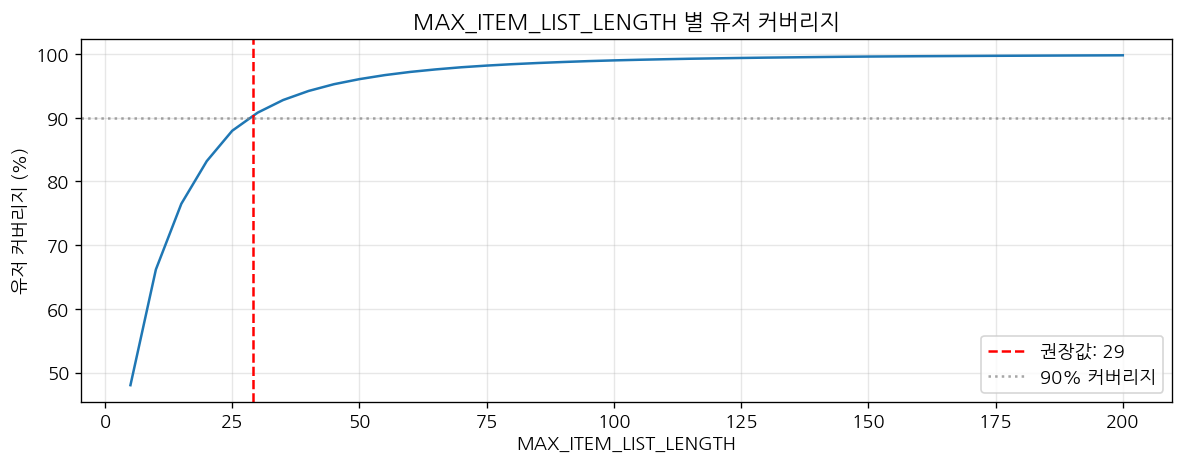

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))
thresholds = range(5, 201, 5)
coverages  = [(seq_len <= t).mean() * 100 for t in thresholds]
ax.plot(list(thresholds), coverages, linewidth=1.5)
ax.axvline(recommended, color='red', linestyle='--', label=f'권장값: {recommended}')
ax.axhline(90, color='gray', linestyle=':', alpha=0.7, label='90% 커버리지')
ax.set_title('MAX_ITEM_LIST_LENGTH 별 유저 커버리지')
ax.set_xlabel('MAX_ITEM_LIST_LENGTH')
ax.set_ylabel('유저 커버리지 (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15. EDA 결과 요약 및 모델 선택 가이드

In [36]:
print('=' * 60)
print('EDA 결과 요약 및 모델 선택 가이드')
print('=' * 60)

print(f'\n[데이터 규모]')
print(f'  유저 수        : {n_users:,}')
print(f'  아이템 수      : {n_items:,}')
print(f'  인터랙션 수    : {len(df):,}')
print(f'  희소성         : {sparsity*100:.4f}%')

print(f'\n[시간 정보]')
print(f'  전체 기간      : {total_days}일')
print(f'  검증 분할 기준 : 마지막 7일 (캘린더 기반)')
print(f'  연속 이벤트 간격 CV   : {cv:.3f}')

print(f'\n[아이템 반복도 — 전 이벤트 기준]')
print(f'  평균 아이템 반복도: {global_repeat_rate*100:.2f}%  (purchase-only 재구매 아님)')

print(f'\n[시퀀스 길이]')
print(f'  권장 MAX_ITEM_LIST_LENGTH: {recommended}')
print(f'  롱 시퀀스(>50) 유저 비율  : {long_seq_ratio*100:.1f}%')

print(f'\n[모델 선택 권고]')
print(f'  ★★★ TiSASRec  — 시간 간격 CV={cv:.2f}, 직접 모델링 필수')
print(f'  ★★★ FEARec    — RecBole 즉시 실험 가능')
print(f'  ★★★ BSARec    — AAAI 2024 최신, NDCG +10~14%')

if global_repeat_rate > 0.10:
    print(f'  ★★★ SAFERec   — 아이템 반복도(전 이벤트) {global_repeat_rate*100:.1f}% → view 빈도 등 NBR·빈도 신호 검토')
    print(f'  ★★☆ TIFU-KNN  — 앙상블 요소로 강력 보완')
else:
    print(f'  ★★☆ SAFERec   — 아이템 반복도 낮음, 효과 미지수')

if long_seq_ratio > 0.20:
    print(f'  ★★☆ Mamba4Rec — 롱 시퀀스 유저 {long_seq_ratio*100:.1f}%, 효율적 처리')
else:
    print(f'  ★☆☆ Mamba4Rec — 롱 시퀀스 유저 비율 낮음, 후순위')

print()
print('[앙상블 초기 가중치 권고]')
w_time  = 0.35 if cv > 1.0 else 0.25
w_freq  = 0.30
w_nbr   = 0.20 if global_repeat_rate > 0.10 else 0.10
w_knn   = 0.15 if global_repeat_rate > 0.10 else 0.05
w_cl    = 1.0 - w_time - w_freq - w_nbr - w_knn
print(f'  TiSASRec : {w_time:.2f}')
print(f'  BSARec   : {w_freq:.2f}')
print(f'  SAFERec  : {w_nbr:.2f}')
print(f'  TIFU-KNN : {w_knn:.2f}')
print(f'  CL4SRec  : {w_cl:.2f}')

EDA 결과 요약 및 모델 선택 가이드

[데이터 규모]
  유저 수        : 638,257
  아이템 수      : 29,502
  인터랙션 수    : 8,350,311
  희소성         : 99.9557%

[시간 정보]
  전체 기간      : 120일
  검증 분할 기준 : 마지막 7일 (캘린더 기반)
  연속 이벤트 간격 CV   : 4.122

[아이템 반복도 — 전 이벤트 기준]
  평균 아이템 반복도: 14.63%  (purchase-only 재구매 아님)

[시퀀스 길이]
  권장 MAX_ITEM_LIST_LENGTH: 29
  롱 시퀀스(>50) 유저 비율  : 4.1%

[모델 선택 권고]
  ★★★ TiSASRec  — 시간 간격 CV=4.12, 직접 모델링 필수
  ★★★ FEARec    — RecBole 즉시 실험 가능
  ★★★ BSARec    — AAAI 2024 최신, NDCG +10~14%
  ★★★ SAFERec   — 아이템 반복도(전 이벤트) 14.6% → view 빈도 등 NBR·빈도 신호 검토
  ★★☆ TIFU-KNN  — 앙상블 요소로 강력 보완
  ★☆☆ Mamba4Rec — 롱 시퀀스 유저 비율 낮음, 후순위

[앙상블 초기 가중치 권고]
  TiSASRec : 0.35
  BSARec   : 0.30
  SAFERec  : 0.20
  TIFU-KNN : 0.15
  CL4SRec  : 0.00
